In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

image_dir = Path.cwd() / "images"
image_files = ["lenna.png", "baboon.png", "barbara.png", "cat.png"]

# No downloads: the images are stored locally in the images/ folder.
# Just verify they are all there before continuing.
missing = [f for f in image_files if not (image_dir / f).exists()]
if missing:
    raise FileNotFoundError(
        "Missing images in the images/ folder: " + ", ".join(missing)
    )

print("Images ready:", ", ".join(image_files))

Images ready: lenna.png, baboon.png, barbara.png, cat.png


## 1. Getting an image into Python

OpenCV reads images as NumPy arrays. That means the image has a shape, a data type, and values that we can inspect just like any other array.

The first useful check is whether the image loaded successfully. Try the inspection commands below before moving on.

In [8]:
image = cv2.imread("images/lenna.png")

print("shape:", image.shape)
print("dtype:", image.dtype)
print("minimum pixel value:", image.min())
print("maximum pixel value:", image.max())

shape: (512, 512, 3)
dtype: uint8
minimum pixel value: 3
maximum pixel value: 255


## 2. Displaying colors correctly

OpenCV stores color images in BGR order, while Matplotlib expects RGB. The image can look strange if we forget to convert between those two conventions.

Use the conversion constant that changes BGR into RGB.

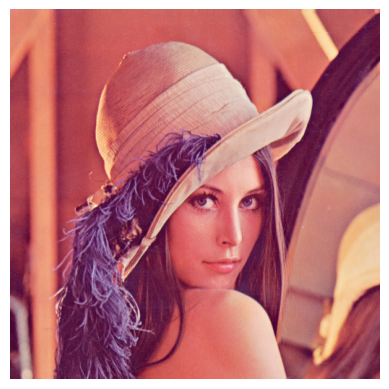

In [9]:
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

## 3. Grayscale and color channels

A grayscale image has one intensity value per pixel instead of three color channels. After converting it, compare its shape with the original image.

The channel order in the original OpenCV image is blue, green, red.

gray shape: (512, 512)


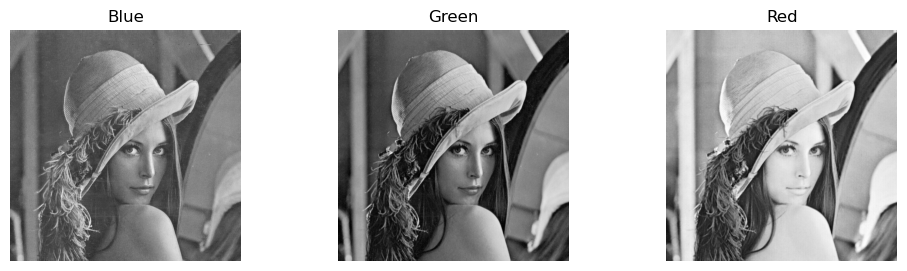

In [7]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("gray shape:", gray_image.shape)

blue = image[:, :, 0]
green = image[:, :, 1]
red = image[:, :, 2]

plt.figure(figsize=(12, 3))
for position, channel, title in [(1, blue, "Blue"), (2, green, "Green"), (3, red, "Red")]:
    plt.subplot(1, 3, position)
    plt.imshow(channel, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.show()

## 4. Copying, aliasing, and cropping

Assigning an array to a second variable does not create a second image. Both names can refer to the same data. Use `.copy()` when an edit should not change the original.

Cropping is just NumPy slicing: rows first, columns second, and channels last.

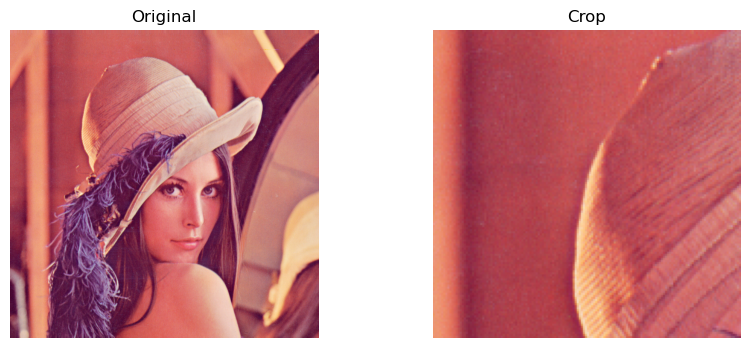

In [10]:
image_copy = image.copy()
image_copy[0:50, 0:50, :] = 0

crop = image[50:200, 50:200, :]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Crop")
plt.axis("off")
plt.show()

## 5. Flipping and drawing

`flipCode=0` flips vertically, `flipCode=1` flips horizontally, and `flipCode=-1` flips both directions.

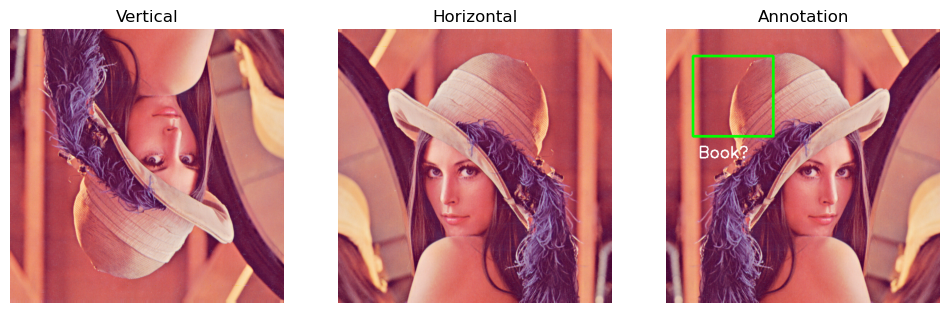

In [11]:
vertical = cv2.flip(image, 0)
horizontal = cv2.flip(image, 1)

annotated = image.copy()
cv2.rectangle(annotated, (50, 50), (200, 200), (0, 255, 0), 3)
cv2.putText(annotated, "Book?", (60, 240), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

plt.figure(figsize=(12, 4))
for position, picture, title in [(1, vertical, "Vertical"), (2, horizontal, "Horizontal"), (3, annotated, "Annotation")]:
    plt.subplot(1, 3, position)
    plt.imshow(cv2.cvtColor(picture, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.show()

## 6. Scaling, translation, and rotation

Geometric transformations change where pixels appear or how many pixels an image contains. Keep track of the order of dimensions: NumPy reports `(rows, columns, channels)`, while OpenCV resize expects `(width, height)` when an explicit size is supplied.

original: (512, 512, 3)
scaled: (256, 256, 3)


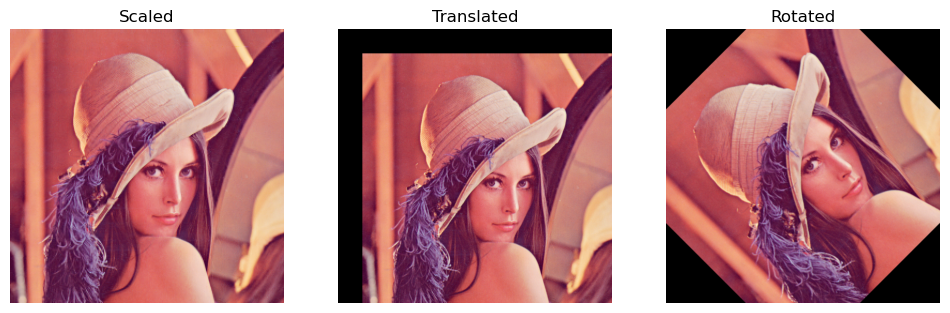

In [12]:
scaled = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
print("original:", image.shape)
print("scaled:", scaled.shape)

rows, cols = image.shape[:2]
tx, ty = 50, 50
translation_matrix = np.float32([[1, 0, tx], [0, 1, ty]])
translated = cv2.warpAffine(image, translation_matrix, (cols + tx, rows + ty))

center = (cols // 2, rows // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(image, rotation_matrix, (cols, rows))

plt.figure(figsize=(12, 4))
for position, picture, title in [(1, scaled, "Scaled"), (2, translated, "Translated"), (3, rotated, "Rotated")]:
    plt.subplot(1, 3, position)
    plt.imshow(cv2.cvtColor(picture, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.show()

## 7. Array arithmetic and noise

An image is an array, so arithmetic is applied element by element. Be careful with `uint8`: it stores values from 0 to 255, and arithmetic can wrap around instead of behaving like ordinary brightness.

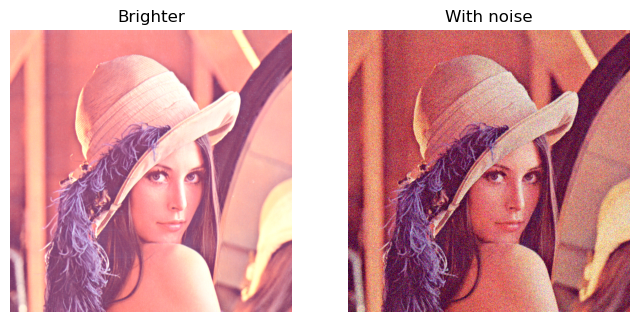

In [14]:
float_image = image.astype(np.float32)
brighter = np.clip(float_image + 50, 0, 255).astype(np.uint8)

noise = np.random.normal(0, 25, image.shape).astype(np.float32)
noisy = np.clip(float_image + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(brighter, cv2.COLOR_BGR2RGB))
plt.title("Brighter")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title("With noise")
plt.axis("off")
plt.show()

## 8. Saving images and file paths

An image is just a file on disk, and `cv2.imwrite` writes a NumPy array back to one. The extension you choose (`.png`, `.jpg`, ...) selects the output format. The `os` module helps build full paths with `os.path.join`.

Fill in the blanks to print the full path of the loaded image and save it as a new `jpg` file.

In [15]:
cwd = os.getcwd()
image_path = os.path.join(cwd, "images", "lenna.jpg")
print("full path:", image_path)

saved = cv2.imwrite("images/lenna_saved.jpg", image)
print("image saved:", saved)

full path: c:\Users\User\TechStack-AI-2026\Week2\Tasks\images\lenna.jpg
image saved: True


## 9. Loading a grayscale image from disk

Instead of converting to grayscale after loading, `imread` can decode the file directly as a single-channel image when the flag parameter is set to `cv2.IMREAD_GRAYSCALE`. Grayscale images must be shown with `cmap="gray"` in Matplotlib.

Fill in the blanks so `barbara.png` loads in grayscale, and print its shape to confirm it only has two dimensions.

barbara_gray shape: (512, 512)


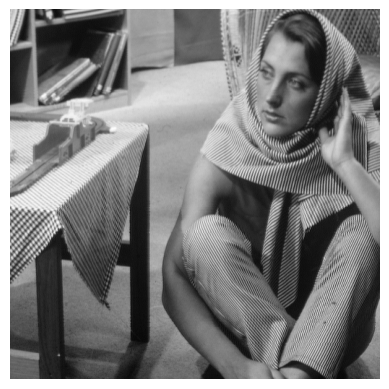

In [16]:
barbara_gray = cv2.imread("images/barbara.png", cv2.IMREAD_GRAYSCALE)
print("barbara_gray shape:", barbara_gray.shape)

plt.imshow(barbara_gray, cmap="gray")
plt.axis("off")
plt.show()

## 10. Isolating color channels

Setting a channel's values to zero removes that color from the image. In the BGR ordering, index 0 is blue, 1 is green, and 2 is red. To keep only the red channel, zero out indices 0 and 1.

Fill in the blanks to create red-only and blue-only versions of `baboon.png`. Work on copies so the original stays untouched.

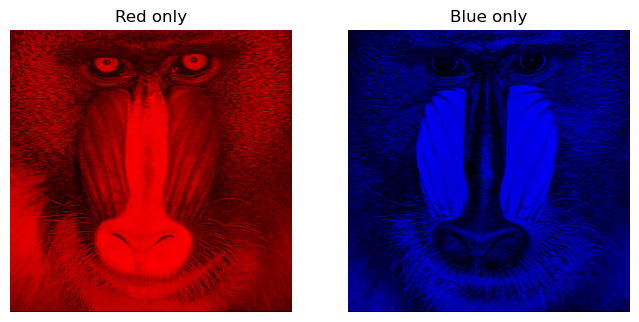

In [18]:
baboon = cv2.imread("images/baboon.png")

baboon_red = baboon.copy()
baboon_red[:, :, 0] = 0
baboon_red[:, :, 1] = 0

baboon_blue = baboon.copy()
baboon_blue[:, :, 1] = 0
baboon_blue[:, :, 2] = 0

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(baboon_red, cv2.COLOR_BGR2RGB))
plt.title("Red only")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(baboon_blue, cv2.COLOR_BGR2RGB))
plt.title("Blue only")
plt.axis("off")
plt.show()

## 11. Rotating by 90 and 180 degrees

Besides `getRotationMatrix2D`, OpenCV offers `cv2.rotate`, which rotates in exact 90-degree steps using built-in constants such as `cv2.ROTATE_90_CLOCKWISE`, `cv2.ROTATE_90_COUNTERCLOCKWISE`, and `cv2.ROTATE_180`.

Fill in the blanks to rotate `cat.png` clockwise by 90 degrees and by 180 degrees.

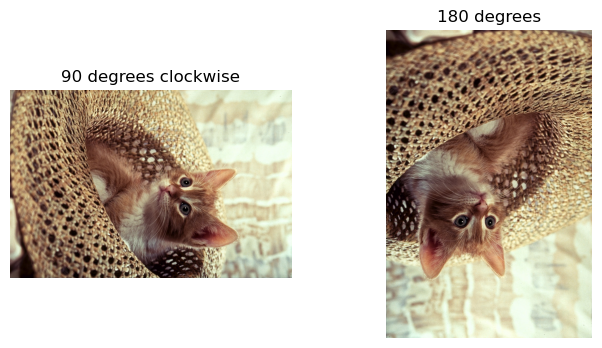

In [20]:
cat = cv2.imread("images/cat.png")

clockwise = cv2.rotate(cat, cv2.ROTATE_90_CLOCKWISE)
half_turn = cv2.rotate(cat, cv2.ROTATE_180)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(clockwise, cv2.COLOR_BGR2RGB))
plt.title("90 degrees clockwise")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(half_turn, cv2.COLOR_BGR2RGB))
plt.title("180 degrees")
plt.axis("off")
plt.show()

## 12. Final exercise

Use `baboon.png` for this exercise. Make a copy, crop a rectangular region, rotate the result, and display the original and edited images side by side. The earlier cells contain every operation you need, but you will need to choose sensible values for the crop and rotation.

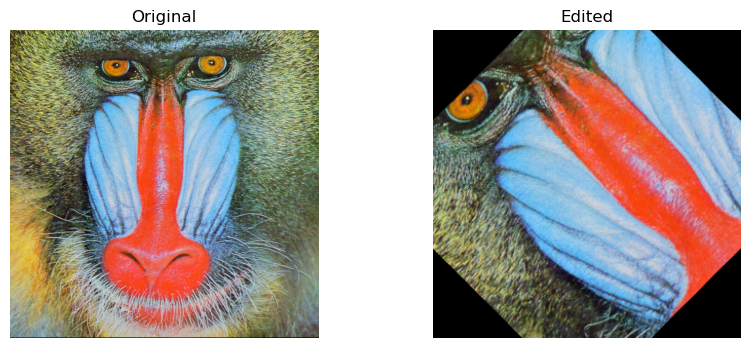

In [22]:
final_image = cv2.imread("images/baboon.png")
final_copy = final_image.copy()
final_crop = final_copy[50:350, 50:350, :]
final_rows, final_cols = final_crop.shape[:2]
final_matrix = cv2.getRotationMatrix2D((final_cols // 2, final_rows // 2), 45, 1.0)
final_rotated = cv2.warpAffine(final_crop, final_matrix, (final_cols, final_rows))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(final_rotated, cv2.COLOR_BGR2RGB))
plt.title("Edited")
plt.axis("off")
plt.show()

## 13. Challenge: building an image puzzle (reusable function)

Time to combine almost everything from this notebook: functions, loops, slicing, and saving files. This version is parameterised, so the same function can build puzzles of any size.

Write a function `make_puzzle(image, image_name, grid_rows, grid_cols)` that:
1. Splits the image into a `grid_rows x grid_cols` grid, so the total number of patches is `grid_rows * grid_cols` (an 8 x 10 grid gives 80 patches, an 8 x 20 grid gives 160).
2. Computes the grid line positions so the split also works when the image size is **not** evenly divisible by the grid: the edge before patch `k` sits at pixel `k * side // patches_along_that_side`, and you need `patches + 1` edge values (from 0 up to the full size).
3. Saves every patch **except the four corner patches** of the grid into `images/[image_name]_puzzle_[total]`, named `[image_name]_patch_[number].png` and numbered in reading order (left to right, top to bottom).
4. Also saves one image that is completely black except for the four corner patches, named `[image_name]_corners.png`.
5. Returns the puzzle folder and the number of saved patches.

Fill in the blanks in the function below, then call it twice to build the 80-patch and the 160-patch version of `baboon.png`.

In [23]:
def make_puzzle(image, image_name, grid_rows, grid_cols):
    rows, cols, _ = image.shape
    total = grid_rows * grid_cols

    row_edges = [k * rows // grid_rows for k in range(grid_rows + 1)]
    col_edges = [k * cols // grid_cols for k in range(grid_cols + 1)]

    puzzle_dir = os.path.join("images", image_name + "_puzzle_" + str(total))
    os.makedirs(puzzle_dir, exist_ok=True)

    corners = np.zeros(image.shape, dtype=np.uint8)
    patch_number = 0

    for i in range(grid_rows):
        for j in range(grid_cols):
            patch = image[row_edges[i]:row_edges[i + 1],
                          col_edges[j]:col_edges[j + 1], :]

            is_corner = (i in (0, grid_rows - 1)) and (j in (0, grid_cols - 1))
            if is_corner:
                corners[row_edges[i]:row_edges[i + 1],
                        col_edges[j]:col_edges[j + 1]] = patch
                continue

            patch_number = patch_number + 1
            patch_name = image_name + "_patch_" + str(patch_number) + ".png"
            cv2.imwrite(os.path.join(puzzle_dir, patch_name), patch)

    corners_path = os.path.join(puzzle_dir, image_name + "_corners" + ".png")
    cv2.imwrite(corners_path, corners)
    print("saved", patch_number, "patches to", puzzle_dir)

    return puzzle_dir, patch_number

In [25]:
puzzle_image = cv2.imread("images/baboon.png")
image_name = "baboon"

puzzle_dir_80, count_80 = make_puzzle(puzzle_image, image_name, 8, 10)
puzzle_dir_160, count_160 = make_puzzle(puzzle_image, image_name, 8, 20)

print("80-patch version:", count_80, "patches saved to", puzzle_dir_80)
print("160-patch version:", count_160, "patches saved to", puzzle_dir_160)

saved 76 patches to images\baboon_puzzle_80
saved 156 patches to images\baboon_puzzle_160
80-patch version: 76 patches saved to images\baboon_puzzle_80
160-patch version: 156 patches saved to images\baboon_puzzle_160


## 14. Your turn

A well-written function should work for any image without changes. Use `make_puzzle` on the other images: build an 80-patch puzzle of `lenna.png` and a 160-patch puzzle of `cat.png`. Then display one of the corners images to check the result.

In [26]:
lenna_dir, lenna_count = make_puzzle(cv2.imread("images/lenna.png"), "lenna", 8, 10)
cat_dir, cat_count = make_puzzle(cv2.imread("images/cat.png"), "cat", 8, 20)

print("lenna:", lenna_count, "patches ->", lenna_dir)
print("cat:", cat_count, "patches ->", cat_dir)

saved 76 patches to images\lenna_puzzle_80
saved 156 patches to images\cat_puzzle_160
lenna: 76 patches -> images\lenna_puzzle_80
cat: 156 patches -> images\cat_puzzle_160


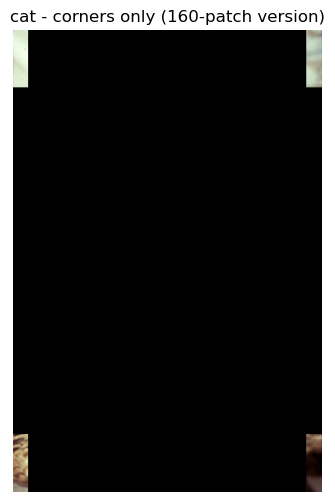

In [27]:
cat_corners = cv2.imread(os.path.join(cat_dir, "cat_corners.png"))

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(cat_corners, cv2.COLOR_BGR2RGB))
plt.title("cat - corners only (160-patch version)")
plt.axis("off")
plt.show()

## 15. Bonus challenge: a shuffled puzzle

Puzzles are no fun in the right order. Write a function `shuffled_puzzle(image, image_name, grid_rows, grid_cols)` that:
1. Makes every patch the **same size** by computing `patch_rows = rows // grid_rows` and `patch_cols = cols // grid_cols`, and cropping the image to `patch_rows * grid_rows` rows and `patch_cols * grid_cols` columns. This is required: shuffled patches can only swap places if they all have the same shape (with an 8 x 10 grid on a 512 pixel image, the edge-based slices are 51 and 52 pixels wide!).
2. Collects **all** `grid_rows x grid_cols` patches of the cropped image in a list (the corners are included this time!).
3. Shuffles the list in place with `np.random.shuffle`.
4. Pastes the shuffled patches one by one back onto a black canvas, in reading order.
5. Saves the result as `images/[image_name]_shuffled.png` and returns it.

Then run it on `baboon` with the 80-patch grid and enjoy the mess.

In [28]:
def shuffled_puzzle(image, image_name, grid_rows, grid_cols):
    rows, cols, _ = image.shape

    patch_rows = rows // grid_rows
    patch_cols = cols // grid_cols
    cropped = image[:patch_rows * grid_rows, :patch_cols * grid_cols, :]

    patches = []
    for i in range(grid_rows):
        for j in range(grid_cols):
            patches.append(cropped[i * patch_rows:(i + 1) * patch_rows,
                                j * patch_cols:(j + 1) * patch_cols, :])

    np.random.shuffle(patches)

    shuffled = np.zeros_like(cropped, dtype=np.uint8)
    number = 0
    for i in range(grid_rows):
        for j in range(grid_cols):
            shuffled[i * patch_rows:(i + 1) * patch_rows,
                     j * patch_cols:(j + 1) * patch_cols] = patches[number]
            number = number + 1

    shuffled_path = os.path.join("images", image_name + "_shuffled" + ".png")
    cv2.imwrite(shuffled_path, shuffled)
    print("saved:", shuffled_path)

    return shuffled

saved: images\baboon_shuffled.png


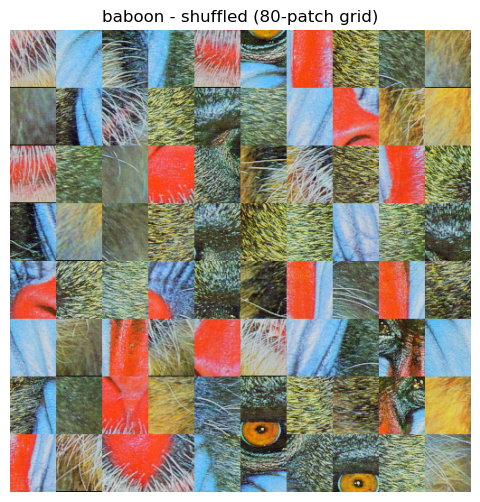

In [29]:
shuffled_baboon = shuffled_puzzle(puzzle_image, image_name, 8, 10)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(shuffled_baboon, cv2.COLOR_BGR2RGB))
plt.title("baboon - shuffled (80-patch grid)")
plt.axis("off")
plt.show()